# First model
 # Transportation Mode Classification

In [2]:
import pandas as pd
import numpy as np

orders_ml = pd.read_csv("../data/orders_analysis_final.csv")

print("Shape:", orders_ml.shape)
print("Duplicate order IDs:", orders_ml["order_id"].duplicated().sum())

Shape: (14243, 73)
Duplicate order IDs: 0


In [3]:

orders_ml = pd.read_csv("../data/orders_analysis_final.csv")

In [4]:
orders_ml.head()

,order_id,customer_id,product_id,quantity,order_date,origin_hub,origin_city,destination_city,destination_state,destination_pincode,...,max_range_km,vehicle_avg_speed_kmph,fleet_status,ownership,distance_per_delivery_hour,vehicle_capacity_utilization_pct,eta_buffer_hours,traffic_vehicle_speed_ratio,weight_exceeds_capacity,distance_level
0,ORD-011545,CUST-02608,PRD-00356,3,2024-05-06 00:00:00+00:00,HUB-LUC,Lucknow,Chandigarh,CH,160017,...,1634.5,52.0,Active,Owned,33.647291,0.137653,4.88,NaN,False,Very Long
1,ORD-008131,CUST-03997,PRD-00200,3,2024-12-27 12:23:00+00:00,HUB-CHE,Chennai,Chennai,TN,600001,...,346.5,45.0,Active,Owned,5.089701,10.060913,0.19,NaN,False,Very Short
2,ORD-005235,CUST-00315,PRD-00222,1,2024-11-18 12:58:00+00:00,HUB-BEN,Bengaluru,Bengaluru,KA,560001,...,311.8,42.0,Active,3PL Partner,9.286822,14.177730,0.31,NaN,False,Very Short
3,ORD-001394,CUST-04067,PRD-00155,4,2024-08-29 11:05:00+00:00,HUB-MAD,Madurai,Madurai,TN,625001,...,1991.3,56.0,Active,Leased,0.588022,0.385889,0.29,NaN,False,Very Short
4,ORD-011091,CUST-04320,PRD-00201,4,2025-04-28 21:44:00+00:00,HUB-AHM,Ahmedabad,Guwahati,AS,781001,...,1126.1,46.0,Retired,Owned,34.059365,1.038232,17.49,NaN,False,Very Long


# Select the ML features and target

In [5]:
transport_features = [
    'quantity',
    'distance_km',
    'package_weight',
    'is_fragile',
    'is_hazmat',
    'cold_chain_required',
    'delivery_priority',
    'order_value_inr',
    'origin_hub',
    'origin_city',
    'destination_city',
    'destination_state',
    'customer_segment',
    'is_prime_member',
    'lifetime_orders'
]

x = orders_ml[transport_features].copy()
y = orders_ml['transport_mode'].copy()

print("Number of features:", len(transport_features))
print("X shape:", x.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (14243, 15)
y shape: (14243,)


# Check missing values only in these ML features

In [6]:
missing = x.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

customer_segment    266
is_prime_member     266
lifetime_orders     266
distance_km         113
dtype: int64


# Fill missing values

In [7]:
# Categorical columns → most common value
x['customer_segment'] = x['customer_segment'].fillna(
    x['customer_segment'].mode()[0]
)

x['is_prime_member'] = x['is_prime_member'].fillna(
    x['is_prime_member'].mode()[0]
)

# Numeric columns → median
x['lifetime_orders'] = x['lifetime_orders'].fillna(
    x['lifetime_orders'].median()
)

x['distance_km'] = x['distance_km'].fillna(
    x['distance_km'].median()
)

print("Missing values filled successfully.")

Missing values filled successfully.


In [8]:
print(x.isnull().sum()[x.isnull().sum() > 0])

Series([], dtype: int64)


# categorical columns

In [9]:
categorical_features = [
    'delivery_priority',
    'origin_hub',
    'origin_city',
    'destination_city',
    'destination_state',
    'customer_segment'
]

for col in categorical_features:
    print("\n", col)
    print(x[col].unique())


 delivery_priority
<ArrowStringArray>
['economy', 'express', 'standard', 'same-day']
Length: 4, dtype: str

 origin_hub
<ArrowStringArray>
['HUB-LUC', 'HUB-CHE', 'HUB-BEN', 'HUB-MAD', 'HUB-AHM', 'HUB-MUM', 'HUB-DEL',
 'HUB-CHA', 'HUB-JAI', 'HUB-GUR', 'HUB-HYD', 'HUB-GUW', 'HUB-BHU', 'HUB-NAG',
 'HUB-KOL', 'HUB-PUN', 'HUB-KOC', 'HUB-COI', 'HUB-VIS', 'HUB-MYS']
Length: 20, dtype: str

 origin_city
<ArrowStringArray>
[      'Lucknow',       'Chennai',     'Bengaluru',       'Madurai',
     'Ahmedabad',        'Mumbai',         'Delhi',    'Chandigarh',
        'Jaipur',      'Gurugram',     'Hyderabad',      'Guwahati',
   'Bhubaneswar',        'Nagpur',       'Kolkata',          'Pune',
         'Kochi',    'Coimbatore', 'Visakhapatnam',        'Mysuru']
Length: 20, dtype: str

 destination_city
<ArrowStringArray>
[   'Chandigarh',       'Chennai',     'Bengaluru',       'Madurai',
      'Guwahati',        'Mumbai',   'Bhubaneswar',        'Jaipur',
     'Ahmedabad',    'Coimbatore',   

# Encoding

# 1. Delivery_priority

In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    categories=[['economy', 'standard', 'express', 'same-day']]
)

x[['delivery_priority']] = encoder.fit_transform(
    x[['delivery_priority']]
)

print("delivery_priority encoded.")

delivery_priority encoded.


In [11]:
print(x['delivery_priority'].value_counts())

delivery_priority
1.0    7134
2.0    3913
3.0    1748
0.0    1448
Name: count, dtype: int64


# 2. customer_segment

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

x['customer_segment'] = le.fit_transform(x['customer_segment'])

print("customer_segment encoded.")

customer_segment encoded.


In [13]:
print(x['customer_segment'].value_counts())

customer_segment
2    4925
0    4578
3    2497
1    2243
Name: count, dtype: int64


# 3. origin_hub

In [14]:
le = LabelEncoder()

x['origin_hub'] = le.fit_transform(x['origin_hub'])

print("origin_hub encoded.")

origin_hub encoded.


In [15]:
print(x['origin_hub'].value_counts())

origin_hub
13    767
6     753
2     744
3     741
7     728
15    724
9     722
18    716
8     715
11    715
10    713
14    708
4     705
0     704
17    698
5     697
16    694
12    678
19    661
1     660
Name: count, dtype: int64


# 4. origin_city

In [16]:
le = LabelEncoder()

x['origin_city'] = le.fit_transform(x['origin_city'])

print("origin_city encoded.")

origin_city encoded.


In [17]:
print(x['origin_city'].value_counts())

origin_city
13    767
6     753
2     744
3     741
7     728
15    724
9     722
18    716
8     715
11    715
10    713
14    708
4     705
0     704
17    698
5     697
16    694
12    678
19    661
1     660
Name: count, dtype: int64


# 5. Destination_city

In [18]:
le = LabelEncoder()

x['destination_city'] = le.fit_transform(x['destination_city'])

print("destination_city encoded.")

destination_city encoded.


In [19]:
print(x['destination_city'].value_counts())

destination_city
0     755
3     749
2     749
7     746
18    744
13    720
9     718
11    713
8     712
17    711
6     710
14    709
4     708
16    706
5     705
10    699
15    685
1     679
12    666
19    659
Name: count, dtype: int64


# 6. destination_state

In [20]:
le = LabelEncoder()

x['destination_state'] = le.fit_transform(x['destination_state'])

print("destination_state encoded.")

destination_state encoded.


In [21]:
print(x['destination_state'].value_counts())

destination_state
8     2140
11    2122
6     1385
4      755
2      749
9      749
5      746
13     720
12     718
7      713
1      712
3      710
10     699
14     666
0      659
Name: count, dtype: int64


# Binary columns

In [22]:
x['is_fragile'] = x['is_fragile'].astype(str).map({
    'False': 0,
    'True': 1,
    'No': 0,
    'Yes': 1,
    '0': 0,
    '1': 1
})

print("is_fragile encoded.")
print(x['is_fragile'].value_counts())

is_fragile encoded.
is_fragile
0    7796
1    6447
Name: count, dtype: int64


is_hazmat

In [23]:
print(x['is_hazmat'].value_counts())

is_hazmat
0    10739
1     3504
Name: count, dtype: int64


cold_chain_required

In [24]:
print(x['cold_chain_required'].value_counts())

cold_chain_required
False    13279
True       964
Name: count, dtype: int64


In [25]:
x['cold_chain_required'] = x['cold_chain_required'].astype(int)

print(x['cold_chain_required'].value_counts())

cold_chain_required
0    13279
1      964
Name: count, dtype: int64


is_prime_member

In [26]:
x['is_prime_member'] = x['is_prime_member'].replace({
    'No': 0,
    'Yes': 1
})

print(x['is_prime_member'].value_counts())

is_prime_member
0    7334
1    6909
Name: count, dtype: int64


In [27]:
x['is_prime_member'] = x['is_prime_member'].astype(int)

print(x['is_prime_member'].dtype)

int64


In [28]:
print("Encoded X shape:", x.shape)
print("\nData types:")
print(x.dtypes)
print("\nMissing values:")
print(x.isnull().sum().sum())

Encoded X shape: (14243, 15)

Data types:
quantity                 int64
distance_km            float64
package_weight         float64
is_fragile               int64
is_hazmat                int64
cold_chain_required      int64
delivery_priority      float64
order_value_inr        float64
origin_hub               int64
origin_city              int64
destination_city         int64
destination_state        int64
customer_segment         int64
is_prime_member          int64
lifetime_orders        float64
dtype: object

Missing values:
0


In [29]:
x

,quantity,distance_km,package_weight,is_fragile,is_hazmat,cold_chain_required,delivery_priority,order_value_inr,origin_hub,origin_city,destination_city,destination_state,customer_segment,is_prime_member,lifetime_orders
0,3,596.23,16.89,0,0,0,0.0,79382.91,13,13,3,2,3,1,118.0
1,3,15.32,87.54,1,0,0,2.0,225352.59,4,4,4,11,3,0,152.0
2,1,11.98,104.66,0,0,0,2.0,49417.12,1,1,1,6,2,1,46.0
3,4,3.24,59.44,0,0,0,1.0,200811.44,14,14,14,11,0,1,68.0
4,4,1962.16,96.92,1,0,0,1.0,523513.96,0,0,8,1,0,0,109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14238,1,8.76,3629.47,0,1,0,1.0,177968.18,16,16,16,6,3,0,182.0
14239,1,11.95,949.03,0,1,0,1.0,120985.15,13,13,13,13,3,1,150.0
14240,4,13.67,2.20,0,0,0,1.0,272314.96,18,18,18,8,0,1,168.0
14241,4,142.07,6282.48,0,1,0,1.0,529671.20,16,16,8,1,2,0,240.0



# Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (11394, 15)
Testing data: (2849, 15)


# Train the classification model

# 1. Logistic Regression

Scale the train and test data

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Train Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Make prediction

In [33]:
y_pred_lr = lr_model.predict(x_test_scaled)

print("Predictions completed.")

Predictions completed.


Calculate Logistic Regression accuracy

In [34]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.6967356967356967


Confusion matrix

In [35]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 232   46    2    0   89   14]
 [   3  665    0    0   15    1]
 [   4  135    0    0   16    1]
 [   2   13    0    0   31    2]
 [  64   80    1    0 1007   21]
 [   3  300    0    0   21   81]]


Classification Report

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

   air cargo       0.75      0.61      0.67       383
        bike       0.54      0.97      0.69       684
       drone       0.00      0.00      0.00       156
        ship       0.00      0.00      0.00        48
       truck       0.85      0.86      0.86      1173
         van       0.68      0.20      0.31       405

    accuracy                           0.70      2849
   macro avg       0.47      0.44      0.42      2849
weighted avg       0.68      0.70      0.65      2849



c:\Users\hp\Desktop\DS_Project_6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\Desktop\DS_Project_6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\Desktop\DS_Project_6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

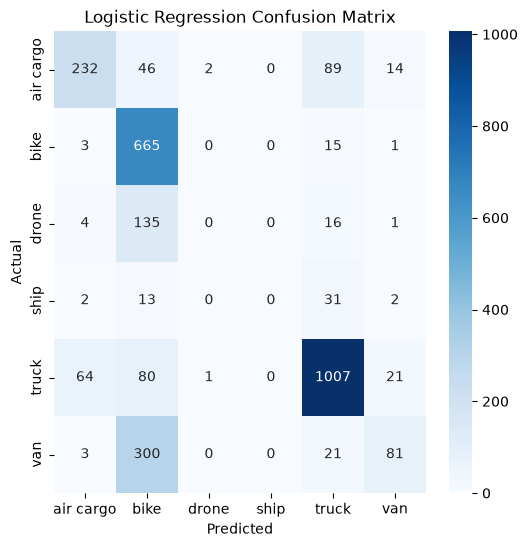

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 2. Random Forest Classifier

Train Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    random_state=42
)

rf_clf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Make predictions

In [39]:
y_pred_rf = rf_clf.predict(x_test)

print("Random Forest predictions completed.")

Random Forest predictions completed.


Random Forest Accuracy

In [40]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",accuracy_rf)

Random Forest Accuracy: 0.9006669006669007


Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 348    8    3    0   18    6]
 [   6  639    9    0   28    2]
 [   4   42   84    0   19    7]
 [   5    8    0    2   28    5]
 [   3   10    3    0 1147   10]
 [   7   29    1    0   22  346]]


classification report

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

   air cargo       0.93      0.91      0.92       383
        bike       0.87      0.93      0.90       684
       drone       0.84      0.54      0.66       156
        ship       1.00      0.04      0.08        48
       truck       0.91      0.98      0.94      1173
         van       0.92      0.85      0.89       405

    accuracy                           0.90      2849
   macro avg       0.91      0.71      0.73      2849
weighted avg       0.90      0.90      0.89      2849



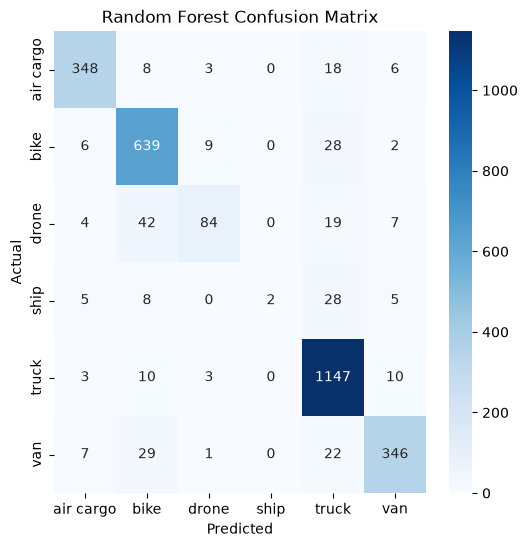

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Create the comparison table

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print("LR metrics restored.")
print("Precision:", round(precision_lr, 4))
print("Recall:", round(recall_lr, 4))
print("F1 Score:", round(f1_lr, 4))

LR metrics restored.
Precision: 0.6777
Recall: 0.6967
F1 Score: 0.6527


In [45]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_lr,
        accuracy_rf
    ],
    'Precision': [
        precision_lr,
        precision_score(y_test, y_pred_rf, average='weighted')
    ],
    'Recall': [
        recall_lr,
        recall_score(y_test, y_pred_rf, average='weighted')
    ],
    'F1 Score': [
        f1_lr,
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print(comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.6967     0.6777  0.6967    0.6527
1        Random Forest    0.9007     0.9017  0.9007    0.8910


# check the correlation method

In [46]:
correlation = x.corr()

print(correlation.round(2))

                     quantity  distance_km  package_weight  is_fragile  \
quantity                 1.00         0.01            0.14       -0.01   
distance_km              0.01         1.00           -0.00       -0.01   
package_weight           0.14        -0.00            1.00       -0.08   
is_fragile              -0.01        -0.01           -0.08        1.00   
is_hazmat                0.02         0.00            0.50        0.07   
cold_chain_required      0.00        -0.01           -0.08        0.10   
delivery_priority       -0.00        -0.01           -0.01        0.00   
order_value_inr          0.58         0.00            0.08       -0.01   
origin_hub              -0.01        -0.03           -0.01        0.00   
origin_city             -0.01        -0.03           -0.01        0.00   
destination_city         0.00        -0.03           -0.01       -0.01   
destination_state       -0.01        -0.04           -0.00        0.00   
customer_segment         0.01         

In [47]:
corr_pairs = correlation.unstack()

corr_pairs = corr_pairs[
    (corr_pairs < 1) &
    (corr_pairs > -1)
]

print(corr_pairs.abs().sort_values(ascending=False).head(10))

quantity             order_value_inr        0.582850
order_value_inr      quantity               0.582850
is_hazmat            package_weight         0.500437
package_weight       is_hazmat              0.500437
cold_chain_required  is_hazmat              0.471689
is_hazmat            cold_chain_required    0.471689
origin_hub           destination_city       0.457887
origin_city          destination_city       0.457887
destination_city     origin_city            0.457887
                     origin_hub             0.457887
dtype: float64


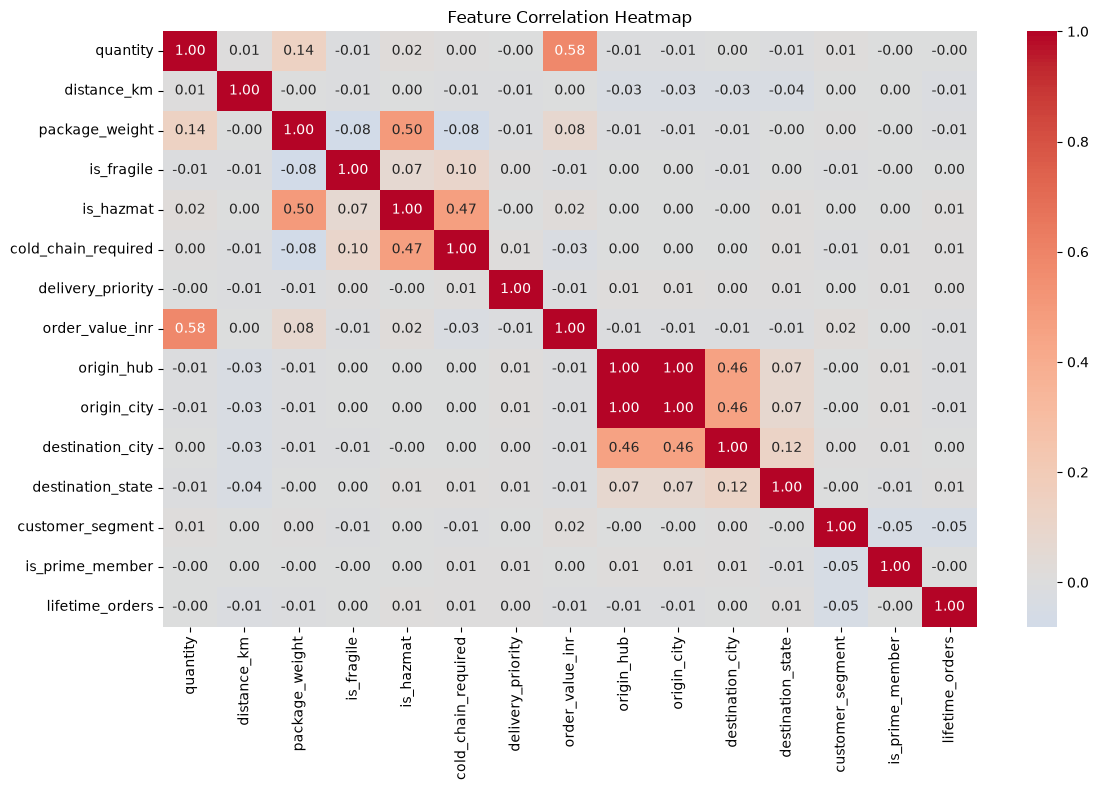

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Final ML summary cell

In [49]:
print("ML MODEL COMPARISON")
print("===================")
print(comparison.round(4))

print("\nBest Model: Random Forest")
print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, average='weighted'), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf, average='weighted'), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf, average='weighted'), 4))

ML MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.6967     0.6777  0.6967    0.6527
1        Random Forest    0.9007     0.9017  0.9007    0.8910

Best Model: Random Forest
Accuracy: 0.9007
Precision: 0.9017
Recall: 0.9007
F1 Score: 0.891


# Save the ML-ready dataset

In [50]:
ml_ready = x.copy()

ml_ready['transport_mode'] = y

ml_ready.to_csv("../data/orders_ml_ready.csv", index=False)

print("ML-ready dataset saved successfully.")
print("Shape:", ml_ready.shape)

ML-ready dataset saved successfully.
Shape: (14243, 16)


In [134]:
from sklearn.ensemble import RandomForestClassifier

rf_models = []

for name, value in list(globals().items()):
    if isinstance(value, RandomForestClassifier):
        rf_models.append((name, value))

print("Random Forest models found:")

for name, model in rf_models:
    print(name)

Random Forest models found:
___
rf_clf
_38
rf_maintenance


# Model Save

In [ ]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/random_forest.pkl", "wb") as file:
    pickle.dump(rf_clf, file)

print("Best Random Forest classification model saved successfully.")

Best Random Forest classification model saved successfully.


# 2. Delivery ETA Prediction

Load the final analysis dataset

In [51]:
import pandas as pd

orders = pd.read_csv("../data/orders_analysis_final.csv")

print("Shape:", orders.shape)
print("Columns:", orders.columns.tolist())

Shape: (14243, 73)
Columns: ['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status', 'delivery_event_count', 'failed_attempt_count', 'rto_count', 'hub_event_count', 'delivery_log_start', 'delivery_log_end', 'vehicle_count', 'delivery_delay_hours', 'delivery_delay_pct', 'on_time', 'order_date_dt', 'traffic_date', 'traffic_hour', 'city_x', 'hour_of_day', 'congestion_index', 'traffic_avg_speed_kmph', 'incident_reported', 'road_closure', 'weather_date', 'weather_city', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmph', 'visibility_km', 'temp_celsius', 'storm_alert', 'condition', 'c

Identify the safe ETA features

In [52]:
eta_features = [
    'quantity',
    'distance_km',
    'package_weight',
    'is_fragile',
    'is_hazmat',
    'cold_chain_required',
    'delivery_priority',
    'order_value_inr',
    'origin_city',
    'destination_city',
    'destination_state',
    'weather_condition_at_dest',
    'humidity_pct',
    'precipitation_mm',
    'wind_speed_kmph',
    'visibility_km',
    'temp_celsius',
    'congestion_index',
    'traffic_avg_speed_kmph',
    'vehicle_type',
    'capacity_kg',
    'vehicle_avg_speed_kmph'
]

eta_target = 'actual_delivery_hours'

print("Number of ETA features:", len(eta_features))
print("Target:", eta_target)

Number of ETA features: 22
Target: actual_delivery_hours


# Check missing values

In [53]:
eta_data = orders[eta_features + [eta_target]].copy()

missing_eta = eta_data.isnull().sum()

print(missing_eta[missing_eta > 0].sort_values(ascending=False))

traffic_avg_speed_kmph    13132
congestion_index          13102
temp_celsius               4983
wind_speed_kmph            1775
precipitation_mm           1775
humidity_pct               1775
visibility_km              1775
capacity_kg                 498
vehicle_type                498
vehicle_avg_speed_kmph      498
distance_km                 113
dtype: int64


Remove the high-missing traffic features

In [54]:
eta_features = [
    'quantity',
    'distance_km',
    'package_weight',
    'is_fragile',
    'is_hazmat',
    'cold_chain_required',
    'delivery_priority',
    'order_value_inr',
    'origin_city',
    'destination_city',
    'destination_state',
    'weather_condition_at_dest',
    'humidity_pct',
    'precipitation_mm',
    'wind_speed_kmph',
    'visibility_km',
    'temp_celsius',
    'vehicle_type',
    'capacity_kg',
    'vehicle_avg_speed_kmph'
]

print("Number of ETA features:", len(eta_features))

Number of ETA features: 20


Check the remaining missing values

In [55]:
eta_data = orders[eta_features + [eta_target]].copy()

missing_eta = eta_data.isnull().sum()

print(missing_eta[missing_eta > 0].sort_values(ascending=False))

temp_celsius              4983
visibility_km             1775
humidity_pct              1775
wind_speed_kmph           1775
precipitation_mm          1775
capacity_kg                498
vehicle_type               498
vehicle_avg_speed_kmph     498
distance_km                113
dtype: int64


Fill numeric missing values

In [56]:
# Numeric column

numeric_eta = [
    'temp_celsius',
    'visibility_km',
    'humidity_pct',
    'wind_speed_kmph',
    'precipitation_mm',
    'capacity_kg',
    'vehicle_avg_speed_kmph',
    'distance_km'
]

for col in numeric_eta:
    eta_data[col] = eta_data[col].fillna(eta_data[col].median())

print("Numeric missing values filled.")

Numeric missing values filled.


Fill the categorical vehicle_type

In [57]:
eta_data['vehicle_type'] = eta_data['vehicle_type'].fillna(
    eta_data['vehicle_type'].mode()[0]
)

print("vehicle_type missing values filled.")

vehicle_type missing values filled.


In [58]:
print(eta_data['vehicle_type'].isnull().sum())

0


Final missing-value check

In [59]:
print("Total missing values:", eta_data.isnull().sum().sum())

Total missing values: 0


fill categorical ETA columns

In [60]:
categorical_eta = [
    'vehicle_type',
    'weather_condition_at_dest',
    'origin_city',
    'destination_city',
    'destination_state'
]


vehicle_type

In [61]:
eta_data['vehicle_type'] = eta_data['vehicle_type'].fillna(
    eta_data['vehicle_type'].mode()[0]
)

print("vehicle_type missing values:", eta_data['vehicle_type'].isnull().sum())

vehicle_type missing values: 0


weather_condition_at_dest

In [62]:
eta_data['weather_condition_at_dest'] = eta_data['weather_condition_at_dest'].fillna(
    eta_data['weather_condition_at_dest'].mode()[0]
)

print(
    "weather_condition_at_dest missing values:",
    eta_data['weather_condition_at_dest'].isnull().sum()
)

weather_condition_at_dest missing values: 0


origin_city

In [63]:
eta_data['origin_city'] = eta_data['origin_city'].fillna(
    eta_data['origin_city'].mode()[0]
)

print(
    "origin_city missing values:",
    eta_data['origin_city'].isnull().sum()
)

origin_city missing values: 0


Destination_city

In [64]:
eta_data['destination_city'] = eta_data['destination_city'].fillna(
    eta_data['destination_city'].mode()[0]
)

print(
    "destination_city missing values:",
    eta_data['destination_city'].isnull().sum()
)

destination_city missing values: 0


Destination_state

In [65]:
eta_data['destination_state'] = eta_data['destination_state'].fillna(
    eta_data['destination_state'].mode()[0]
)

print(
    "destination_state missing values:",
    eta_data['destination_state'].isnull().sum()
)

destination_state missing values: 0


In [66]:
print("Total missing values:", eta_data.isnull().sum().sum())

Total missing values: 0


# Encoding

1. Encode vehicle_type

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

eta_data['vehicle_type'] = le.fit_transform(
    eta_data['vehicle_type']
)

print("vehicle_type encoded.")
print(eta_data['vehicle_type'].value_counts())

vehicle_type encoded.
vehicle_type
4    6141
1    3298
5    1953
0    1856
2     759
3     236
Name: count, dtype: int64


2. weather_condition_at_dest

In [68]:
le = LabelEncoder()

eta_data['weather_condition_at_dest'] = le.fit_transform(
    eta_data['weather_condition_at_dest']
)

print("weather_condition_at_dest encoded.")
print(eta_data['weather_condition_at_dest'].value_counts())

weather_condition_at_dest encoded.
weather_condition_at_dest
0    5485
1    2689
4    2437
5    1256
2     852
3     827
6     697
Name: count, dtype: int64


3. origin_city

In [69]:
le = LabelEncoder()

eta_data['origin_city'] = le.fit_transform(
    eta_data['origin_city']
)

print("origin_city encoded.")
print(eta_data['origin_city'].value_counts())

origin_city encoded.
origin_city
13    767
6     753
2     744
3     741
7     728
15    724
9     722
18    716
8     715
11    715
10    713
14    708
4     705
0     704
17    698
5     697
16    694
12    678
19    661
1     660
Name: count, dtype: int64


4. Destination_city

In [70]:
le = LabelEncoder()

eta_data['destination_city'] = le.fit_transform(
    eta_data['destination_city']
)

print("destination_city encoded.")
print(eta_data['destination_city'].value_counts())

destination_city encoded.
destination_city
0     755
3     749
2     749
7     746
18    744
13    720
9     718
11    713
8     712
17    711
6     710
14    709
4     708
16    706
5     705
10    699
15    685
1     679
12    666
19    659
Name: count, dtype: int64


5. Destination_state

In [71]:
le = LabelEncoder()

eta_data['destination_state'] = le.fit_transform(
    eta_data['destination_state']
)

print("destination_state encoded.")
print(eta_data['destination_state'].value_counts())

destination_state encoded.
destination_state
8     2140
11    2122
6     1385
4      755
2      749
9      749
5      746
13     720
12     718
7      713
1      712
3      710
10     699
14     666
0      659
Name: count, dtype: int64


Final ETA dataset check

In [72]:
print("ETA data shape:", eta_data.shape)

print("\nMissing values:")
print(eta_data.isnull().sum().sum())

print("\nData types:")
print(eta_data.dtypes)

ETA data shape: (14243, 21)

Missing values:
0

Data types:
quantity                       int64
distance_km                  float64
package_weight               float64
is_fragile                       str
is_hazmat                      int64
cold_chain_required             bool
delivery_priority                str
order_value_inr              float64
origin_city                    int64
destination_city               int64
destination_state              int64
weather_condition_at_dest      int64
humidity_pct                 float64
precipitation_mm             float64
wind_speed_kmph              float64
visibility_km                float64
temp_celsius                 float64
vehicle_type                   int64
capacity_kg                  float64
vehicle_avg_speed_kmph       float64
actual_delivery_hours        float64
dtype: object


Check is_fragile

In [73]:
print(eta_data['is_fragile'].value_counts())

is_fragile
False    3851
True     3241
0        1997
No       1948
1        1649
Yes      1557
Name: count, dtype: int64


Encode is_fragile

In [74]:
eta_data['is_fragile'] = eta_data['is_fragile'].replace({
    'False': 0,
    'True': 1,
    'No': 0,
    'Yes': 1,
    '0': 0,
    '1': 1
})

eta_data['is_fragile'] = eta_data['is_fragile'].astype(int)

print("is_fragile encoded.")
print(eta_data['is_fragile'].value_counts())

is_fragile encoded.
is_fragile
0    7796
1    6447
Name: count, dtype: int64


Delivery_priority

In [75]:
print(eta_data['delivery_priority'].value_counts())

delivery_priority
standard    7134
express     3913
same-day    1748
economy     1448
Name: count, dtype: int64


delivery_priority

In [76]:
eta_data['delivery_priority'] = eta_data['delivery_priority'].map({
    'economy': 0,
    'standard': 1,
    'express': 2,
    'same-day': 3
})

print("delivery_priority encoded.")
print(eta_data['delivery_priority'].value_counts().sort_index())

delivery_priority encoded.
delivery_priority
0    1448
1    7134
2    3913
3    1748
Name: count, dtype: int64


cold_chain_required

In [77]:
print(eta_data['cold_chain_required'].value_counts())

cold_chain_required
False    13279
True       964
Name: count, dtype: int64


In [78]:
eta_data['cold_chain_required'] = eta_data['cold_chain_required'].astype(int)

print("cold_chain_required encoded.")
print(eta_data['cold_chain_required'].value_counts())

cold_chain_required encoded.
cold_chain_required
0    13279
1      964
Name: count, dtype: int64


Final data-type check

In [79]:
print("ETA data shape:", eta_data.shape)

print("\nMissing values:", eta_data.isnull().sum().sum())

print("\nData types:")
print(eta_data.dtypes)

ETA data shape: (14243, 21)

Missing values: 0

Data types:
quantity                       int64
distance_km                  float64
package_weight               float64
is_fragile                     int64
is_hazmat                      int64
cold_chain_required            int64
delivery_priority              int64
order_value_inr              float64
origin_city                    int64
destination_city               int64
destination_state              int64
weather_condition_at_dest      int64
humidity_pct                 float64
precipitation_mm             float64
wind_speed_kmph              float64
visibility_km                float64
temp_celsius                 float64
vehicle_type                   int64
capacity_kg                  float64
vehicle_avg_speed_kmph       float64
actual_delivery_hours        float64
dtype: object


# Train/Test Split

In [80]:
x_eta = eta_data.drop('actual_delivery_hours', axis=1)
y_eta = eta_data['actual_delivery_hours']

print("X shape:", x_eta.shape)
print("y shape:", y_eta.shape)

X shape: (14243, 20)
y shape: (14243,)


In [81]:
from sklearn.model_selection import train_test_split

x_eta_train, x_eta_test, y_eta_train, y_eta_test = train_test_split(
    x_eta,
    y_eta,
    test_size=0.20,
    random_state=42
)

print("Training data:", x_eta_train.shape)
print("Testing data:", x_eta_test.shape)

Training data: (11394, 20)
Testing data: (2849, 20)


# 1. Linear Regression

In [82]:
from sklearn.linear_model import LinearRegression

lr_eta = LinearRegression()

lr_eta.fit(x_eta_train, y_eta_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-0.07, 0.02, 0. ,..., 1.32, 0. ,-0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['quantity','distance_km','package_weight',...,'vehicle_type', 'capacity_kg','vehicle_avg_speed_kmph']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.241
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


Make ETA predictions

In [83]:
y_pred_lr_eta = lr_eta.predict(x_eta_test)

print("Linear Regression predictions completed.")

Linear Regression predictions completed.


# Calculate MAE

    MAE (Mean Absolute Error)

In [84]:
from sklearn.metrics import mean_absolute_error

mae_lr_eta = mean_absolute_error(
    y_eta_test,
    y_pred_lr_eta
)

print("Linear Regression MAE:", round(mae_lr_eta, 4))

Linear Regression MAE: 5.585


MSE (Mean square error)

In [85]:
from sklearn.metrics import mean_squared_error

mse_lr_eta = mean_squared_error(
    y_eta_test,
    y_pred_lr_eta
)

print("Linear Regression MSE:", round(mse_lr_eta, 4))

Linear Regression MSE: 84.5122


RMSE (Root mean square error)

In [86]:
from sklearn.metrics import root_mean_squared_error

rmse_lr_eta = root_mean_squared_error(
    y_eta_test,
    y_pred_lr_eta
)

print("Linear Regression RMSE:", round(rmse_lr_eta, 4))

Linear Regression RMSE: 9.1931


R² Score

In [87]:
from sklearn.metrics import r2_score

r2_lr_eta = r2_score(
    y_eta_test,
    y_pred_lr_eta
)

print("Linear Regression R² Score:", round(r2_lr_eta, 4))

Linear Regression R² Score: 0.7069


# 2. Random Forest Regressor

In [88]:
from sklearn.ensemble import RandomForestRegressor

rf_eta = RandomForestRegressor(
    random_state=42
)

rf_eta.fit(x_eta_train, y_eta_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Make ETA predictions

In [89]:
y_pred_rf_eta = rf_eta.predict(x_eta_test)

print("Random Forest ETA predictions completed.")

Random Forest ETA predictions completed.


Random Forest MAE

In [90]:
from sklearn.metrics import mean_absolute_error

mae_rf_eta = mean_absolute_error(
    y_eta_test,
    y_pred_rf_eta
)

print("Random Forest MAE:", round(mae_rf_eta, 4))

Random Forest MAE: 2.2675


Random Forest MSE

In [91]:
from sklearn.metrics import mean_squared_error

mse_rf_eta = mean_squared_error(
    y_eta_test,
    y_pred_rf_eta
)

print("Random Forest MSE:", round(mse_rf_eta, 4))

Random Forest MSE: 25.737


Random Forest RMSE

In [92]:
from sklearn.metrics import root_mean_squared_error

rmse_rf_eta = root_mean_squared_error(
    y_eta_test,
    y_pred_rf_eta
)

print("Random Forest RMSE:", round(rmse_rf_eta, 4))

Random Forest RMSE: 5.0732


Random Forest R²

In [93]:
from sklearn.metrics import r2_score

r2_rf_eta = r2_score(
    y_eta_test,
    y_pred_rf_eta
)

print("Random Forest R² Score:", round(r2_rf_eta, 4))

Random Forest R² Score: 0.9107


# Create the ETA model comparison table

In [94]:
eta_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mae_lr_eta,
        mae_rf_eta
    ],
    'MSE': [
        mse_lr_eta,
        mse_rf_eta
    ],
    'RMSE': [
        rmse_lr_eta,
        rmse_rf_eta
    ],
    'R2 Score': [
        r2_lr_eta,
        r2_rf_eta
    ]
})

print(eta_comparison.round(4))

               Model     MAE      MSE    RMSE  R2 Score
0  Linear Regression  5.5850  84.5122  9.1931    0.7069
1      Random Forest  2.2675  25.7370  5.0732    0.9107


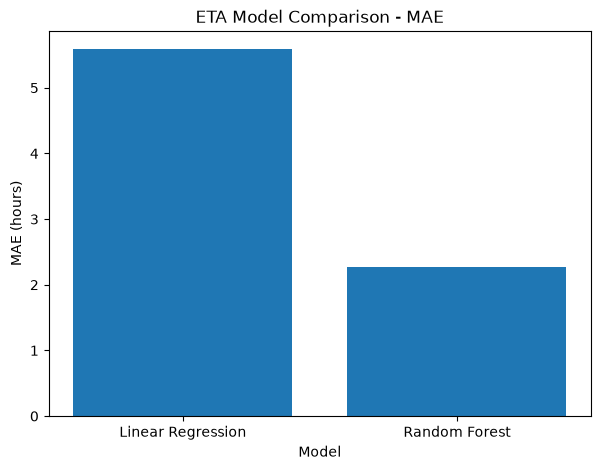

In [95]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
mae_values = [mae_lr_eta, mae_rf_eta]

plt.figure(figsize=(7, 5))

plt.bar(models, mae_values)

plt.xlabel("Model")
plt.ylabel("MAE (hours)")
plt.title("ETA Model Comparison - MAE")

plt.show()

# Actual vs Predicted chart for Random Forest

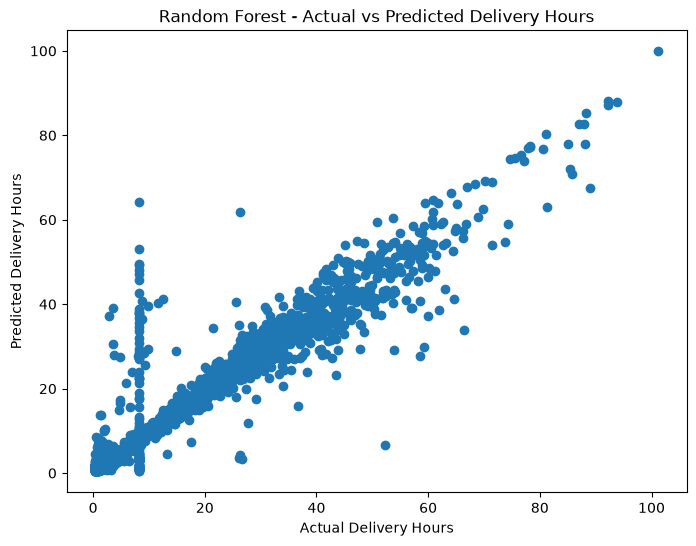

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_eta_test, y_pred_rf_eta)

plt.xlabel("Actual Delivery Hours")
plt.ylabel("Predicted Delivery Hours")
plt.title("Random Forest - Actual vs Predicted Delivery Hours")

plt.show()

# save the ETA-ready dataset

In [97]:
eta_data.to_csv(
    "../data/orders_eta_ready.csv",
    index=False
)

print("ETA-ready dataset saved successfully.")

ETA-ready dataset saved successfully.


In [137]:
from sklearn.base import RegressorMixin

for name, value in list(globals().items()):
    if isinstance(value, RegressorMixin):
        print(name, type(value).__name__)

_ RandomForestRegressor
__ LinearRegression
lr_eta LinearRegression
_82 LinearRegression
rf_eta RandomForestRegressor
_88 RandomForestRegressor


# Save Model

In [138]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/eta_model.pkl", "wb") as file:
    pickle.dump(rf_eta, file)

print("Best ETA Random Forest model saved successfully.")

Best ETA Random Forest model saved successfully.


# 3. Predictive Maintenance using ML

Identify the maintenance target

In [98]:
maintenance_cols = [
    'vehicle_id',
    'vehicle_type',
    'capacity_kg',
    'max_range_km',
    'vehicle_avg_speed_kmph',
    'fleet_status',
    'ownership',
    'vehicle_capacity_utilization_pct',
    'weight_exceeds_capacity'
]

print(orders[maintenance_cols].head())

  vehicle_id vehicle_type  capacity_kg  max_range_km  vehicle_avg_speed_kmph  \
0   VEH-0698        Truck      12270.0        1634.5                    52.0   
1   VEH-0478          Van        870.1         346.5                    45.0   
2   VEH-0524          Van        738.2         311.8                    42.0   
3   VEH-0594        Truck      15403.4        1991.3                    56.0   
4   VEH-0669        Truck       9335.1        1126.1                    46.0   

  fleet_status    ownership  vehicle_capacity_utilization_pct  \
0       Active        Owned                          0.137653   
1       Active        Owned                         10.060913   
2       Active  3PL Partner                         14.177730   
3       Active       Leased                          0.385889   
4      Retired        Owned                          1.038232   

   weight_exceeds_capacity  
0                    False  
1                    False  
2                    False  
3           

Check fleet_status

In [99]:
print(orders['fleet_status'].value_counts())

fleet_status
Active         5474
Maintenance    3360
Retired        1896
Idle           1525
In Service     1490
Name: count, dtype: int64


Create the target

In [100]:
orders['maintenance_required'] = (
    orders['fleet_status'] == 'Maintenance'
).astype(int)

print(orders['maintenance_required'].value_counts())

maintenance_required
0    10883
1     3360
Name: count, dtype: int64


Select maintenance features

In [101]:
maintenance_features = [
    'vehicle_type',
    'capacity_kg',
    'max_range_km',
    'vehicle_avg_speed_kmph',
    'ownership',
    'vehicle_capacity_utilization_pct',
    'weight_exceeds_capacity',
    'distance_km',
    'delivery_event_count',
    'failed_attempt_count',
    'rto_count',
    'hub_event_count'
]

print("Number of maintenance features:", len(maintenance_features))

Number of maintenance features: 12


Create the maintenance dataset

In [102]:
maintenance_data = orders[
    maintenance_features + ['maintenance_required']
].copy()

print("Maintenance data shape:", maintenance_data.shape)

Maintenance data shape: (14243, 13)


 # Check missing values

In [103]:
print(maintenance_data.isnull().sum())

vehicle_type                         498
capacity_kg                          498
max_range_km                         498
vehicle_avg_speed_kmph               498
ownership                            498
vehicle_capacity_utilization_pct    1351
weight_exceeds_capacity                0
distance_km                          113
delivery_event_count                 498
failed_attempt_count                 498
rto_count                            498
hub_event_count                      498
maintenance_required                   0
dtype: int64


# Numeric missing values

In [104]:
numeric_maintenance = [
    'capacity_kg',
    'max_range_km',
    'vehicle_avg_speed_kmph',
    'vehicle_capacity_utilization_pct',
    'distance_km',
    'delivery_event_count',
    'failed_attempt_count',
    'rto_count',
    'hub_event_count'
]

for col in numeric_maintenance:
    maintenance_data[col] = maintenance_data[col].fillna(
        maintenance_data[col].median()
    )

print("Numeric missing values filled.")

Numeric missing values filled.


# vehicle_type

In [105]:
maintenance_data['vehicle_type'] = maintenance_data['vehicle_type'].fillna(
    maintenance_data['vehicle_type'].mode()[0]
)

print(
    "vehicle_type missing values:",
    maintenance_data['vehicle_type'].isnull().sum()
)

vehicle_type missing values: 0


# ownership

In [106]:
maintenance_data['ownership'] = maintenance_data['ownership'].fillna(
    maintenance_data['ownership'].mode()[0]
)

print(
    "ownership missing values:",
    maintenance_data['ownership'].isnull().sum()
)

ownership missing values: 0


# Final missing-value check

In [107]:
print("Total missing values:", maintenance_data.isnull().sum().sum())

Total missing values: 0


# Encoding

1. vehicle_type

In [108]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

maintenance_data['vehicle_type'] = le.fit_transform(
    maintenance_data['vehicle_type']
)

print("vehicle_type encoded.")
print(maintenance_data['vehicle_type'].value_counts())

vehicle_type encoded.
vehicle_type
4    6141
1    3298
5    1953
0    1856
2     759
3     236
Name: count, dtype: int64


2. ownership

In [109]:
le = LabelEncoder()

maintenance_data['ownership'] = le.fit_transform(
    maintenance_data['ownership']
)

print("ownership encoded.")
print(maintenance_data['ownership'].value_counts())

ownership encoded.
ownership
0    5088
1    4590
2    4565
Name: count, dtype: int64


Final maintenance dataset check

In [110]:
print("Maintenance data shape:", maintenance_data.shape)

print("\nMissing values:", maintenance_data.isnull().sum().sum())

print("\nData types:")
print(maintenance_data.dtypes)

Maintenance data shape: (14243, 13)

Missing values: 0

Data types:
vehicle_type                          int64
capacity_kg                         float64
max_range_km                        float64
vehicle_avg_speed_kmph              float64
ownership                             int64
vehicle_capacity_utilization_pct    float64
weight_exceeds_capacity                bool
distance_km                         float64
delivery_event_count                float64
failed_attempt_count                float64
rto_count                           float64
hub_event_count                     float64
maintenance_required                  int64
dtype: object


3. weight_exceeds_capacity

In [111]:
maintenance_data['weight_exceeds_capacity'] = (
    maintenance_data['weight_exceeds_capacity'].astype(int)
)

print(maintenance_data['weight_exceeds_capacity'].value_counts())

weight_exceeds_capacity
0    13390
1      853
Name: count, dtype: int64


# Create X_maintenance and y_maintenance

In [112]:
x_maintenance = maintenance_data.drop(
    'maintenance_required',
    axis=1
)

y_maintenance = maintenance_data['maintenance_required']

print("X shape:", x_maintenance.shape)
print("y shape:", y_maintenance.shape)

X shape: (14243, 12)
y shape: (14243,)


# Train/Test Split

In [113]:
from sklearn.model_selection import train_test_split

x_maintenance_train, x_maintenance_test, y_maintenance_train, y_maintenance_test = train_test_split(
    x_maintenance,
    y_maintenance,
    test_size=0.20,
    random_state=42,
    stratify=y_maintenance
)

print("Training data:", x_maintenance_train.shape)
print("Testing data:", x_maintenance_test.shape)

Training data: (11394, 12)
Testing data: (2849, 12)


# 1. Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression

lr_maintenance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_maintenance.fit(
    x_maintenance_train,
    y_maintenance_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


c:\Users\hp\Desktop\DS_Project_6\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scale the maintenance features

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_maintenance_train_scaled = scaler.fit_transform(
    x_maintenance_train
)

x_maintenance_test_scaled = scaler.transform(
    x_maintenance_test
)

print("Maintenance features scaled successfully.")

Maintenance features scaled successfully.


In [116]:
lr_maintenance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_maintenance.fit(
    x_maintenance_train_scaled,
    y_maintenance_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


Make predictions

In [117]:
y_pred_lr_maintenance = lr_maintenance.predict(
    x_maintenance_test_scaled
)

print("Logistic Regression predictions completed.")

Logistic Regression predictions completed.


# Precision
    The project requires Precision, Recall, F1-score, and Confusion Matrix for Predictive Maintenance

In [118]:
from sklearn.metrics import precision_score

precision_lr_maintenance = precision_score(
    y_maintenance_test,
    y_pred_lr_maintenance
)

print(
    "Logistic Regression Precision:",
    round(precision_lr_maintenance, 4)
)

Logistic Regression Precision: 1.0


# Recall

In [119]:
from sklearn.metrics import recall_score

recall_lr_maintenance = recall_score(
    y_maintenance_test,
    y_pred_lr_maintenance
)

print(
    "Logistic Regression Recall:",
    round(recall_lr_maintenance, 4)
)

Logistic Regression Recall: 0.0104


# F1-score

In [120]:
from sklearn.metrics import f1_score

f1_lr_maintenance = f1_score(
    y_maintenance_test,
    y_pred_lr_maintenance
)

print(
    "Logistic Regression F1 Score:",
    round(f1_lr_maintenance, 4)
)

Logistic Regression F1 Score: 0.0206


# Logistic Regression confusion matrix

In [121]:
from sklearn.metrics import confusion_matrix

cm_lr_maintenance = confusion_matrix(
    y_maintenance_test,
    y_pred_lr_maintenance
)

print(cm_lr_maintenance)

[[2177    0]
 [ 665    7]]


# 2. Random Forest Classifier

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf_maintenance = RandomForestClassifier(
    random_state=42
)

rf_maintenance.fit(
    x_maintenance_train,
    y_maintenance_train
)

print("Random Forest maintenance model trained successfully.")

Random Forest maintenance model trained successfully.


# Make Random Forest predictions

In [123]:
y_pred_rf_maintenance = rf_maintenance.predict(
    x_maintenance_test
)

print("Random Forest predictions completed.")

Random Forest predictions completed.


# Random Forest Precision

In [124]:
from sklearn.metrics import precision_score

precision_rf_maintenance = precision_score(
    y_maintenance_test,
    y_pred_rf_maintenance
)

print(
    "Random Forest Precision:",
    round(precision_rf_maintenance, 4)
)

Random Forest Precision: 1.0


# Random Forest Recall

In [125]:
from sklearn.metrics import recall_score

recall_rf_maintenance = recall_score(
    y_maintenance_test,
    y_pred_rf_maintenance
)

print(
    "Random Forest Recall:",
    round(recall_rf_maintenance, 4)
)

Random Forest Recall: 0.8839


# Random Forest F1-score

In [126]:
from sklearn.metrics import f1_score

f1_rf_maintenance = f1_score(
    y_maintenance_test,
    y_pred_rf_maintenance
)

print(
    "Random Forest F1 Score:",
    round(f1_rf_maintenance, 4)
)

Random Forest F1 Score: 0.9384


# Random Forest Confusion Matrix

In [127]:
from sklearn.metrics import confusion_matrix

cm_rf_maintenance = confusion_matrix(
    y_maintenance_test,
    y_pred_rf_maintenance
)

print(cm_rf_maintenance)

[[2177    0]
 [  78  594]]


Final Predictive Maintenance comparison

In [128]:
print("Logistic Regression F1 Score:", round(f1_lr_maintenance, 4))

Logistic Regression F1 Score: 0.0206


# Create the model comparison chart

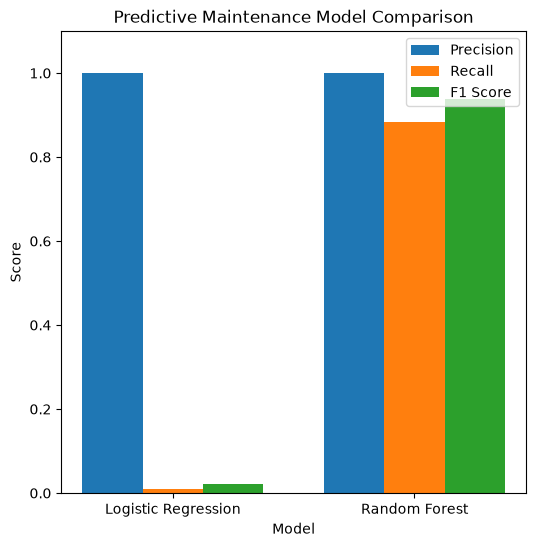

In [129]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Random Forest']

precision_values = [
    precision_lr_maintenance,
    precision_rf_maintenance
]

recall_values = [
    recall_lr_maintenance,
    recall_rf_maintenance
]

f1_values = [
    f1_lr_maintenance,
    f1_rf_maintenance
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(6,6))

plt.bar(x - width, precision_values, width, label='Precision')
plt.bar(x, recall_values, width, label='Recall')
plt.bar(x + width, f1_values, width, label='F1 Score')

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Predictive Maintenance Model Comparison")

plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend()

plt.show()

# save the maintenance-ready dataset

In [130]:
maintenance_data.to_csv(
    "../data/orders_maintenance_ready.csv",
    index=False
)

print("Maintenance-ready dataset saved successfully.")

Maintenance-ready dataset saved successfully.


In [139]:
from sklearn.base import ClassifierMixin

for name, value in list(globals().items()):
    if isinstance(value, ClassifierMixin):
        print(name, type(value).__name__)

___ RandomForestClassifier
lr_model LogisticRegression
_32 LogisticRegression
rf_clf RandomForestClassifier
_38 RandomForestClassifier
lr_maintenance LogisticRegression
rf_maintenance RandomForestClassifier
model RandomForestClassifier


# Save Model

In [140]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/maintenance_model.pkl", "wb") as file:
    pickle.dump(rf_maintenance, file)

print("Best Predictive Maintenance model saved successfully.")

Best Predictive Maintenance model saved successfully.
